## Support Vector Regression Implementation

In [1]:
## Datasets (Tips Dataset)

import seaborn as sns
df=sns.load_dataset('tips')

In [2]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [5]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [6]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [7]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [8]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [9]:
# Seperating Independent and dependent features

X = df[['tip','sex','smoker','day','time','size']]
y = df['total_bill']

In [10]:
## Train test split
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
X_train.head()

,tip,sex,smoker,day,time,size
115,3.50,Female,No,Sun,Dinner,2
181,5.65,Male,Yes,Sun,Dinner,2
225,2.50,Female,Yes,Fri,Lunch,2
68,2.01,Male,No,Sat,Dinner,2
104,4.08,Female,No,Sat,Dinner,2


## Feature Encoding(Label Encoding and Onehot Encoding)

Step 1: Create Preprocessor

You don’t need LabelEncoder here.

Use OneHotEncoder directly.

In [12]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['sex','smoker','day','time']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'category_transform',
            OneHotEncoder(drop='first',handle_unknown='ignore'),
            categorical_features
        )
    ],remainder='passthrough'
)

### Step 2: Create Pipeline

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

pipeline  = Pipeline([
    ('preprocessing',preprocessor),
    ('model',SVR())
])

In [14]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('category_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [15]:
y_pred = pipeline.predict(X_test)

In [16]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R2 Score: 0.49798620106004743
MAE: 4.463296539661221
MSE: 39.31122612339172
RMSE: 6.269866515595983


## Hyperparameter Tuning using GridSearch CV

In [17]:
from sklearn.model_selection import GridSearchCV
 
# defining parameter range
param_grid = {'model__C': [0.1, 1, 10, 100, 1000],
              'model__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'model__kernel': ['rbf']}

In [18]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    refit = True,
    verbose=3
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END model__C=0.1, model__gamma=1, model__kernel=rbf;, score=-0.114 total time=   0.0s
[CV 2/5] END model__C=0.1, model__gamma=1, model__kernel=rbf;, score=-0.008 total time=   0.0s
[CV 3/5] END model__C=0.1, model__gamma=1, model__kernel=rbf;, score=-0.003 total time=   0.0s
[CV 4/5] END model__C=0.1, model__gamma=1, model__kernel=rbf;, score=-0.015 total time=   0.0s
[CV 5/5] END model__C=0.1, model__gamma=1, model__kernel=rbf;, score=-0.123 total time=   0.0s
[CV 1/5] END model__C=0.1, model__gamma=0.1, model__kernel=rbf;, score=0.019 total time=   0.0s
[CV 2/5] END model__C=0.1, model__gamma=0.1, model__kernel=rbf;, score=0.096 total time=   0.0s
[CV 3/5] END model__C=0.1, model__gamma=0.1, model__kernel=rbf;, score=0.078 total time=   0.0s
[CV 4/5] END model__C=0.1, model__gamma=0.1, model__kernel=rbf;, score=0.099 total time=   0.0s
[CV 5/5] END model__C=0.1, model__gamma=0.1, model__kernel=rbf;, score=-0.020 t

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': [1, 0.1, ...], 'model__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [19]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)
results.sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__gamma,param_model__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
17,0.002558,0.000371,0.001244,0.000096,100.0,0.0100,rbf,"{'model__C': 100, 'model__gamma': 0.01, 'model...",0.607036,0.686720,0.387517,0.683086,0.238457,0.520563,0.178205,1
22,0.003183,0.000338,0.001304,0.000085,1000.0,0.0100,rbf,"{'model__C': 1000, 'model__gamma': 0.01, 'mode...",0.643642,0.709078,0.430519,0.640053,0.177515,0.520161,0.195322,2
23,0.002492,0.000185,0.001227,0.000048,1000.0,0.0010,rbf,"{'model__C': 1000, 'model__gamma': 0.001, 'mod...",0.620570,0.673729,0.360170,0.676849,0.229652,0.512194,0.183244,3
11,0.002682,0.000461,0.001406,0.000297,10.0,0.1000,rbf,"{'model__C': 10, 'model__gamma': 0.1, 'model__...",0.598880,0.632643,0.430686,0.595040,0.246287,0.500707,0.145311,4
24,0.002230,0.000139,0.001253,0.000197,1000.0,0.0001,rbf,"{'model__C': 1000, 'model__gamma': 0.0001, 'mo...",0.536452,0.659236,0.375456,0.657592,0.212453,0.488238,0.172640,5
18,0.002313,0.000262,0.001401,0.000335,100.0,0.0010,rbf,"{'model__C': 100, 'model__gamma': 0.001, 'mode...",0.536188,0.657211,0.376329,0.654962,0.214554,0.487848,0.170923,6
12,0.002334,0.000293,0.001282,0.000126,10.0,0.0100,rbf,"{'model__C': 10, 'model__gamma': 0.01, 'model_...",0.530284,0.629205,0.382613,0.628871,0.216365,0.477468,0.158687,7
16,0.002925,0.000143,0.001285,0.000051,100.0,0.1000,rbf,"{'model__C': 100, 'model__gamma': 0.1, 'model_...",0.344130,0.687442,0.414222,0.442125,0.286487,0.434881,0.137494,8
10,0.002473,0.000178,0.002030,0.001365,10.0,1.0000,rbf,"{'model__C': 10, 'model__gamma': 1, 'model__ke...",0.326866,0.538557,0.529215,0.248748,0.336355,0.395948,0.116695,9
6,0.002226,0.000105,0.001199,0.000040,1.0,0.1000,rbf,"{'model__C': 1, 'model__gamma': 0.1, 'model__k...",0.493095,0.466556,0.330431,0.425329,0.203722,0.383827,0.105636,10


In [20]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Best Parameters:
{'model__C': 100, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Best CV Score:
0.520562967103466


In [21]:
grid_prediction = grid.predict(X_test)

In [22]:
print("R² Score :", r2_score(y_test, grid_prediction))
print("MAE      :", mean_absolute_error(y_test, grid_prediction))
print("MSE      :", mean_squared_error(y_test, grid_prediction))
print("RMSE     :", root_mean_squared_error(y_test, grid_prediction))

R² Score : 0.5630706781167809
MAE      : 4.260495176171524
MSE      : 34.21465188558678
RMSE     : 5.84932918252912


In [23]:
y_pred = pipeline.predict(X_test)
print("Original R²:", r2_score(y_test, y_pred))

grid_prediction = grid.predict(X_test)
print("Tuned R²:", r2_score(y_test, grid_prediction))

Original R²: 0.49798620106004743
Tuned R²: 0.5630706781167809


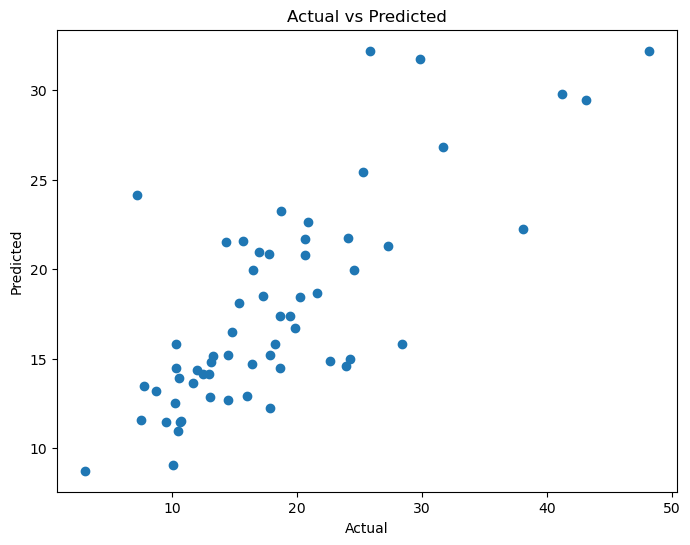

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, grid_prediction)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [25]:
train_score = grid.score(X_train, y_train)
test_score = grid.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.5617014453212228
Test R² : 0.5630706781167809
